#### European Ski Resorts - Machine Learning (Unsupervised)
This notebook covers:

1. **Dimensionality Reduction** Applying Principal Component Analysis to compress complex features into key patterns
2. **K-Means Cluster Selection** Evaluating metrics using Elbow Method (WCSS/Inertia) and Silhouette Score to determine optimal number of clusters
3. **Clustering & Profiling** Fitting K-Means on ski resort dataset to profile distinct cluster characteristics.

Output: `ski_resorts_unsupervised.csv`

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns

In [47]:
df_unsupervised = pd.read_csv('../data/ski_resorts_ML.csv')

In [48]:
df_unsupervised.head()

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,resort_size_category,CountryGrouped
0,Alpendorf (Ski amedé),Austria,1980,740,52.0,30,81,4,115,1,0,22,16,11,49,75398,600,1240,Very Large,Austria
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47.0,100,77,33,210,1,1,37,28,7,72,99017,1032,930,Very Large,Andorra
2,Oberau (Wildschönau),Austria,1130,900,30.0,1,0,1,2,0,0,2,0,0,2,1932,0,230,Small,Austria
3,Dachstein West,Austria,1620,780,42.0,15,33,3,51,1,1,25,8,3,36,32938,163,840,Large,Austria
4,Rosa Khutor,Southern Russia,2320,940,22.0,30,26,21,77,1,0,6,11,10,27,49228,450,1380,Large,Other


#### **<u>Assessing Feature Correlation for PCA**</u>
Checking correlation across resort metrics. High correlation between features (such as `HighestPoint and VerticalDrop at 0.84) can indicate redundant variance that PCA can condense.

In [49]:
df_unsupervised['HighestPoint'].corr(df_unsupervised['DayPassPriceAdult'])

0.5037687995604236

In [50]:
df_unsupervised['HighestPoint'].corr(df_unsupervised['VerticalDrop'])

0.8383334185990572

#### <u>**Feature Selection for Unsupervised Pipeline (PCA -> K-Means)**</u>
Selected features to be standardized using `StandardScaler()` to prevent variance distortion. The 7 features focuses on physical resort amenities, excluding price targets so PCA can compress the most important dimensions while preserving dataset variance. 

In [51]:
# List of features to incorporate into PCA -> Kmeans 

X = ['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'VerticalDrop', 'SnowCannons', 'GondolaLifts', 'ChairLifts']

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_unsupervised[X])


In [53]:
pca_= PCA(n_components=None)

In [54]:
pca_ski_resorts = pca_.fit_transform(X_scaled)
print(pca_ski_resorts)

[[ 1.17511109 -0.16535368 -0.92297329 ...  0.55099712 -0.73644097
  -0.10385271]
 [ 2.63559408 -1.2607334   0.13568143 ...  0.43674118  0.71011834
  -0.37153992]
 [-2.00014524 -0.81683436  0.30843922 ... -0.08925497  0.04517318
   0.00533556]
 ...
 [ 1.79700785  1.36026991 -1.31935104 ...  0.75544348 -0.22005671
   0.05508219]
 [ 1.79700785  1.36026991 -1.31935104 ...  0.75544348 -0.22005671
   0.05508219]
 [-0.59213909  0.35398592 -0.46633096 ... -0.21613448 -0.08633425
  -0.02110724]]


#### <u>**Explained Variance Ratio : What percentage of dataset's total variance is captured by each PCA?**</u>

In [55]:
pca_.explained_variance_ratio_

array([0.75098268, 0.1017494 , 0.06587232, 0.0346322 , 0.02147164,
       0.01636524, 0.00892652])

#### **<u>PCA - Explained Variance: How much information does each principal component holds? </u>**
When we set `n_components` = None, we get a matrix of 7 rows, 7 columns comprised our features in `pca_.components`. 

PC1 explains 75% of data variation  
PC2 explains 10.17% of data variation   
PC3 explains 6.58 % of data variation  
 
Together, PC1, PC2 and PC3 explains 91.75% of data variation

#### PCA represents the overall resort scale. To interpret the PCA components, each component combines the weighted score of the 7 original features into a single score

In [56]:
pca_.components_

array([[ 0.40412298,  0.40227114,  0.37765783,  0.29048336,  0.36619466,
         0.39081428,  0.40127571],
       [-0.25672032,  0.10483173,  0.23049867,  0.79880593, -0.40941917,
        -0.01549273, -0.25302245],
       [ 0.0824123 ,  0.32872746,  0.57177596, -0.40125779, -0.50286316,
        -0.3524124 ,  0.14193327],
       [-0.37024136,  0.17242698,  0.28541814, -0.33474948,  0.06618064,
         0.62466669, -0.49505676],
       [-0.4491544 ,  0.600131  , -0.11665184,  0.02667997,  0.46747332,
        -0.45065465, -0.04650501],
       [ 0.15667712, -0.43279117,  0.55374345,  0.06123771,  0.4650212 ,
        -0.35150296, -0.37143394],
       [ 0.63294664,  0.37673601, -0.27498037, -0.00126699, -0.07905796,
        -0.07731271, -0.60795173]])

In [57]:
components_df = pd.DataFrame(pca_.components_, index=[f'PC{i+1}' for i in range (pca_.components_.shape[0])], columns=X)

In [58]:
print(components_df)

     BeginnerSlope  IntermediateSlope  DifficultSlope  VerticalDrop  \
PC1       0.404123           0.402271        0.377658      0.290483   
PC2      -0.256720           0.104832        0.230499      0.798806   
PC3       0.082412           0.328727        0.571776     -0.401258   
PC4      -0.370241           0.172427        0.285418     -0.334749   
PC5      -0.449154           0.600131       -0.116652      0.026680   
PC6       0.156677          -0.432791        0.553743      0.061238   
PC7       0.632947           0.376736       -0.274980     -0.001267   

     SnowCannons  GondolaLifts  ChairLifts  
PC1     0.366195      0.390814    0.401276  
PC2    -0.409419     -0.015493   -0.253022  
PC3    -0.502863     -0.352412    0.141933  
PC4     0.066181      0.624667   -0.495057  
PC5     0.467473     -0.450655   -0.046505  
PC6     0.465021     -0.351503   -0.371434  
PC7    -0.079058     -0.077313   -0.607952  


In [59]:
components_df.loc[['PC1', 'PC2']]

,BeginnerSlope,IntermediateSlope,DifficultSlope,VerticalDrop,SnowCannons,GondolaLifts,ChairLifts
PC1,0.404123,0.402271,0.377658,0.290483,0.366195,0.390814,0.401276
PC2,-0.256720,0.104832,0.230499,0.798806,-0.409419,-0.015493,-0.253022


I decided to include only 2 principal components (PC1 and PC2) they together accounted for `~85%` of the total variance in the dataset. Setting the `n_components=2` features to 2 dimensions to preserve the data's information. 

While intermediate slope count is the strongest predictor of price (supervised finding), it does not dominate the resorts' overall structural variation (unsupervised finding) — beginner and intermediate slope counts vary together across resorts at similar magnitudes. This suggests intermediate terrain specifically carries pricing power beyond what its overall variability alone would suggest.

In [60]:
optimal_pca = PCA(n_components=2)
reduced_dataset= optimal_pca.fit_transform(X_scaled)

reduced_df = pd.DataFrame(reduced_dataset, columns=['PC1', 'PC2'])
print(reduced_df)

          PC1       PC2
0    1.175111 -0.165354
1    2.635594 -1.260733
2   -2.000145 -0.816834
3   -0.677919 -0.197404
4    0.816234  0.400470
..        ...       ...
359  4.379574  1.276545
360  4.379574  1.276545
361  1.797008  1.360270
362  1.797008  1.360270
363 -0.592139  0.353986

[364 rows x 2 columns]


In [61]:
reduced_dataset

array([[ 1.17511109e+00, -1.65353683e-01],
       [ 2.63559408e+00, -1.26073340e+00],
       [-2.00014524e+00, -8.16834358e-01],
       [-6.77918785e-01, -1.97404020e-01],
       [ 8.16234274e-01,  4.00470067e-01],
       [-1.88326482e+00, -8.95531235e-01],
       [-8.40954845e-01,  1.06363058e+00],
       [-1.26237252e+00, -1.86821118e-01],
       [-1.16757757e+00,  2.51554304e-01],
       [-1.32642961e+00,  1.32894197e-01],
       [-1.70788977e+00, -6.30053573e-01],
       [-1.72107365e+00, -5.33018227e-01],
       [-1.41019933e+00, -2.67276497e-01],
       [-1.23036937e+00,  1.14734849e-01],
       [-1.89503831e+00, -6.95201811e-01],
       [ 1.10685885e+01, -1.79970520e+00],
       [ 1.10685885e+01, -1.79970520e+00],
       [ 2.72310689e+00,  5.31351197e-01],
       [ 3.76136424e+00, -1.70795827e-01],
       [ 3.30980179e+00, -1.34527985e-01],
       [ 1.80720735e+00,  1.21337781e+00],
       [ 8.10749413e-01,  2.33417474e-01],
       [ 6.01348244e-01, -1.24219564e+00],
       [ 1.

#### **<u>Calculating Inertia for Elbow Method Analysis</u>**
We calculate Within-Cluster Sum of Squares (inertia) across different cluster counts in order to locate optimal k. The Elbow method is one way to determine k clusters for K-Means. 

In [62]:
results = []
reduced_df
for i in range(1, 11):
     kmeans = KMeans(n_clusters=i)
     kmeans.fit(reduced_dataset)
     results.append(kmeans.inertia_)
results

[2172.7613637303866,
 828.3761764939454,
 587.5363630457969,
 329.7316379627723,
 309.2305609585353,
 204.9838067639202,
 189.55880783662812,
 157.96653965458063,
 128.98534568774232,
 113.97075250585257]

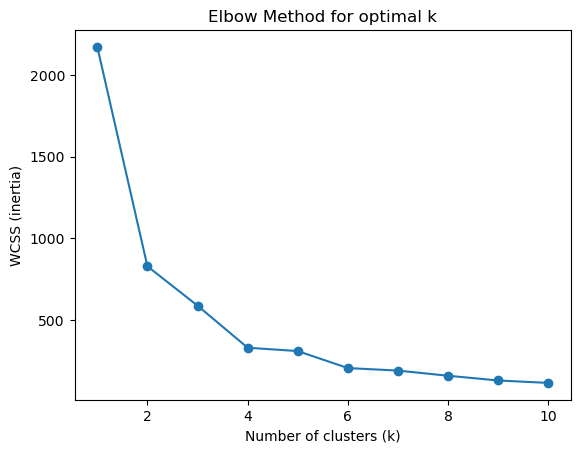

In [63]:
plt.plot(range(1,11), results, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method for optimal k')
plt.show()

####  The Elbow method is subjective as we see the drop starts to flatten around k=3, k=4. I've opted to go with k=4

In [64]:
reduced_df['Resort'] = df_unsupervised['Resort'].values
reduced_df['Country'] = df_unsupervised['Country'].values

In [65]:
reduced_df

,PC1,PC2,Resort,Country
0,1.175111,-0.165354,Alpendorf (Ski amedé),Austria
1,2.635594,-1.260733,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra
2,-2.000145,-0.816834,Oberau (Wildschönau),Austria
3,-0.677919,-0.197404,Dachstein West,Austria
4,0.816234,0.400470,Rosa Khutor,Southern Russia
...,...,...,...,...
359,4.379574,1.276545,Montgenèvre (Via Lattea),France
360,4.379574,1.276545,Sauze d’Oulx (Via Lattea),Italy
361,1.797008,1.360270,Gressoney - La-Trinite (Monterosa Ski),Italy
362,1.797008,1.360270,Champoluc (Monterosa Ski),Italy


#### Filtering for resorts with `PC1 > 7` represents resorts where their scale and lift infrastructure sits beyond the standalone resorts. Les 3 Vallees is the world's largest interconnected ski domain, hence why several resorts all share the same PC1, PC2 metrics such as Meribel, Les menuires and Courchevel. 

In [66]:
reduced_df[reduced_df['PC1'] >7 ]

,PC1,PC2,Resort,Country
15,11.068589,-1.799705,Méribel (Les 3 Vallées),France
16,11.068589,-1.799705,​Les Menuires (Les 3 Vallées),France
254,11.068589,-1.799705,Courchevel (Les 3 Vallées),France
255,7.866953,-1.791386,Les Gets (Les Portes du Soleil),France
256,7.866953,-1.791386,Avoriaz (Les Portes du Soleil),France
257,7.866953,-1.791386,Châtel (Les Portes du Soleil),France
270,11.068589,-1.799705,Saint Martin de Belleville (Les 3 Vallées),France
318,11.068589,-1.799705,La Tania-Val Thorens/​Les Menuires/​Méribel (...,France
358,11.068589,-1.799705,Val Thorens (Les 3 Vallées),France


In [67]:
reduced_dataset

array([[ 1.17511109e+00, -1.65353683e-01],
       [ 2.63559408e+00, -1.26073340e+00],
       [-2.00014524e+00, -8.16834358e-01],
       [-6.77918785e-01, -1.97404020e-01],
       [ 8.16234274e-01,  4.00470067e-01],
       [-1.88326482e+00, -8.95531235e-01],
       [-8.40954845e-01,  1.06363058e+00],
       [-1.26237252e+00, -1.86821118e-01],
       [-1.16757757e+00,  2.51554304e-01],
       [-1.32642961e+00,  1.32894197e-01],
       [-1.70788977e+00, -6.30053573e-01],
       [-1.72107365e+00, -5.33018227e-01],
       [-1.41019933e+00, -2.67276497e-01],
       [-1.23036937e+00,  1.14734849e-01],
       [-1.89503831e+00, -6.95201811e-01],
       [ 1.10685885e+01, -1.79970520e+00],
       [ 1.10685885e+01, -1.79970520e+00],
       [ 2.72310689e+00,  5.31351197e-01],
       [ 3.76136424e+00, -1.70795827e-01],
       [ 3.30980179e+00, -1.34527985e-01],
       [ 1.80720735e+00,  1.21337781e+00],
       [ 8.10749413e-01,  2.33417474e-01],
       [ 6.01348244e-01, -1.24219564e+00],
       [ 1.

#### Silhouette Score: As the Elbow Method is subjective and relies on visual interpretation, I wanted to confirm for k using Silhouette Score using mathematical analysis.  The Silhouette Score measures how similar an object is to its own cluster as compared to other clusters.  

In [68]:
kmeans_results = []


for i in range(2, 11):
     kmeans_model = KMeans(n_clusters=i)
     kmeans_model.fit(reduced_dataset)
     score = silhouette_score(X=reduced_dataset, labels=kmeans_model.labels_)
     kmeans_results.append(score)
     print(f'\nK = {i} , Silhouette score:  {score:.4f}')
kmeans_results




K = 2 , Silhouette score:  0.7157

K = 3 , Silhouette score:  0.4885

K = 4 , Silhouette score:  0.4467

K = 5 , Silhouette score:  0.4198

K = 6 , Silhouette score:  0.4253

K = 7 , Silhouette score:  0.3915

K = 8 , Silhouette score:  0.3907

K = 9 , Silhouette score:  0.4172

K = 10 , Silhouette score:  0.4012


[0.715663230130845,
 0.4884706084143692,
 0.4466681841983461,
 0.4198254716873935,
 0.42529016678219006,
 0.39152635406383324,
 0.3906801946915201,
 0.4171763384526136,
 0.40124288556553583]

#### **<u>Silhouette Score - Evaluation</u>** 
The peak silhouette score is when K = 2 with a silhouette score of  
`.7157`.  When presented with these 2 differing tradeoffs, selecting k=2 vs k=4, if we select k=2, there'll be 2 defined clusters representing 2 grouped segments such as 'Small Resorts' vs 'Large/Mega Resorts.'   

But by selecting k=4 (moderate silhouette score of `0.4456`), there may be interesting sub-groups with patterns that may not have seen before. 

#### **<u>Evaluating K-Means Cluster Solutions (k= 2 vs k = 4)</u>**

In [69]:
# k=4
kmeans4 = KMeans(n_clusters=4, random_state=44)
kmeans4.fit(reduced_dataset)

KMeans(n_clusters=4, random_state=44)

In [70]:
# k = 2 
kmeans2 = KMeans(n_clusters=2, random_state=44)
kmeans2.fit(reduced_dataset)

KMeans(n_clusters=2, random_state=44)

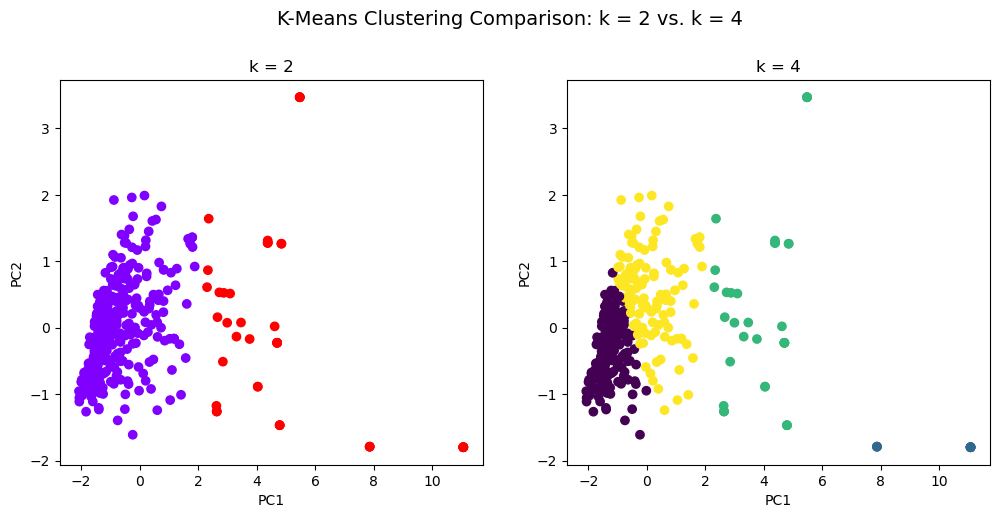

In [71]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].scatter(reduced_df['PC1'], reduced_df['PC2'], c=kmeans2.labels_, cmap = 'rainbow')
axes[0].set_title('k = 2')

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(reduced_df['PC1'], reduced_df['PC2'], c = kmeans4.labels_, cmap = 'viridis')
axes[1].set_title('k = 4')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
fig.suptitle('K-Means Clustering Comparison: k = 2 vs. k = 4', fontsize=14, y=1.02)
plt.show()

#### **<u>Difference in Cluster groupings</u>** 
We observe that when k=2, the points in the dataset are all grouped in 2 different segments, each corresponding to whether it's a small resort vs large/megasize resort. Observe when k=4, there's 4 different segments of groups (small/budget, mid-size resort, large resort and megasize resorts at the far end where PC1 > 7). This provides a richer look into the different segments for comparative analysis. 

In [72]:
# Assigning 'Cluster' column to labels attribute so we can see which data point belongs to which cluster 
df_unsupervised['Cluster'] = kmeans4.labels_

In [73]:
summary = df_unsupervised.groupby('Cluster')[['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'VerticalDrop', 'SnowCannons', 'GondolaLifts', 'ChairLifts']].mean()

In [74]:
summary

,BeginnerSlope,IntermediateSlope,DifficultSlope,VerticalDrop,SnowCannons,GondolaLifts,ChairLifts
Cluster,,,,,,,
0,13.857895,14.068421,3.684211,641.515789,66.052632,0.994737,3.952632
1,311.333333,214.000000,68.000000,1902.000000,1946.666667,30.333333,66.666667
2,102.750000,132.527778,44.611111,1676.972222,734.833333,13.305556,28.972222
3,33.736434,39.131783,11.697674,1325.387597,198.170543,4.155039,8.620155


In [75]:
reduced_df

,PC1,PC2,Resort,Country
0,1.175111,-0.165354,Alpendorf (Ski amedé),Austria
1,2.635594,-1.260733,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra
2,-2.000145,-0.816834,Oberau (Wildschönau),Austria
3,-0.677919,-0.197404,Dachstein West,Austria
4,0.816234,0.400470,Rosa Khutor,Southern Russia
...,...,...,...,...
359,4.379574,1.276545,Montgenèvre (Via Lattea),France
360,4.379574,1.276545,Sauze d’Oulx (Via Lattea),Italy
361,1.797008,1.360270,Gressoney - La-Trinite (Monterosa Ski),Italy
362,1.797008,1.360270,Champoluc (Monterosa Ski),Italy


In [76]:
df_unsupervised['Cluster']

0      3
1      2
2      0
3      0
4      3
      ..
359    2
360    2
361    3
362    3
363    3
Name: Cluster, Length: 364, dtype: int32

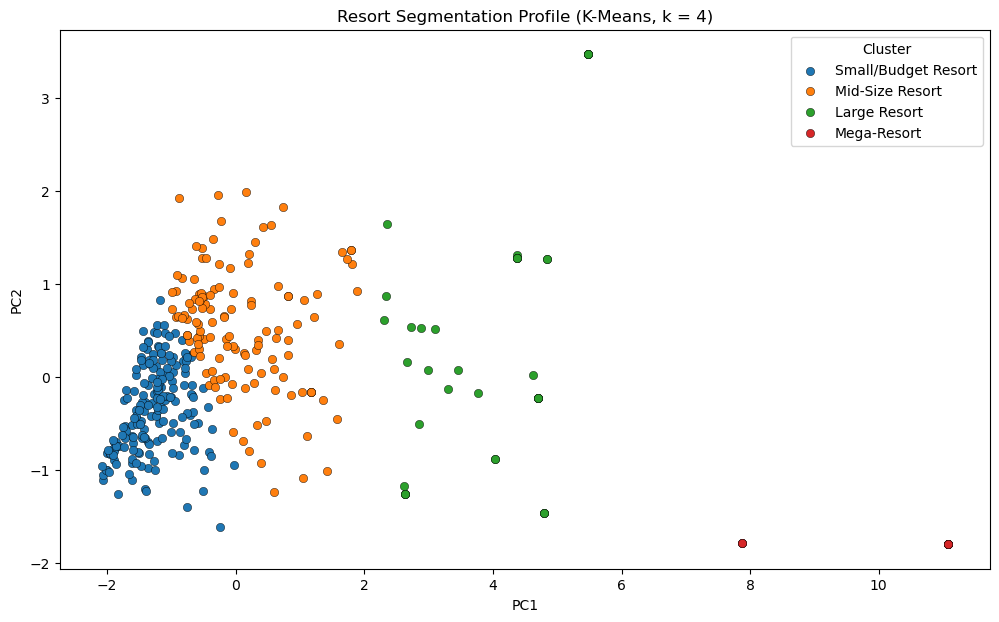

In [77]:
fig, ax = plt.subplots(figsize = (12,7))

cluster_names = {0: 'Small/Budget Resort', 3: 'Mid-Size Resort', 2: 'Large Resort', 1: 'Mega-Resort'}

df_unsupervised['Cluster_Name'] = df_unsupervised['Cluster'].map(cluster_names)

# ax.scatter(reduced_df['PC1'], reduced_df['PC2'], c = kmeans4.labels_, cmap = 'tab10', edgecolors='black', linewidths=0.3)

for cluster_num, name in cluster_names.items():
    subset = reduced_df[df_unsupervised['Cluster'] == cluster_num]
    ax.scatter(subset['PC1'], subset['PC2'], label=name, edgecolors='black', linewidths=0.3)


ax.set_title('Resort Segmentation Profile (K-Means, k = 4)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

ax.legend(title= 'Cluster')
plt.show()

#### **Business & Value-Focused** 
**<u>Price Analysis: Average Day Pass by Resort Segment</u>**

Here we can see for each tiered resort by group, the average day pass cost. By mapping the average pricing back to the clusters, we can evaluate relative value. This informs us whether a particular resort may be undervalued, overvalued or priced just right relative to their physical amenities and scale. 

In [78]:
avg_price_grouped_clusters = df_unsupervised.groupby('Cluster_Name')['DayPassPriceAdult'].mean()
avg_price_grouped_clusters

Cluster_Name
Large Resort           53.611111
Mega-Resort            57.666667
Mid-Size Resort        45.604651
Small/Budget Resort    36.210526
Name: DayPassPriceAdult, dtype: float64

In [79]:
df_unsupervised

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,...,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,resort_size_category,CountryGrouped,Cluster,Cluster_Name
0,Alpendorf (Ski amedé),Austria,1980,740,52.0,30,81,4,115,1,...,16,11,49,75398,600,1240,Very Large,Austria,3,Mid-Size Resort
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47.0,100,77,33,210,1,...,28,7,72,99017,1032,930,Very Large,Andorra,2,Large Resort
2,Oberau (Wildschönau),Austria,1130,900,30.0,1,0,1,2,0,...,0,0,2,1932,0,230,Small,Austria,0,Small/Budget Resort
3,Dachstein West,Austria,1620,780,42.0,15,33,3,51,1,...,8,3,36,32938,163,840,Large,Austria,0,Small/Budget Resort
4,Rosa Khutor,Southern Russia,2320,940,22.0,30,26,21,77,1,...,11,10,27,49228,450,1380,Large,Other,3,Mid-Size Resort
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,Montgenèvre (Via Lattea),France,2749,1372,48.0,96,220,84,400,0,...,35,7,71,96433,0,1377,Very Large,France,2,Large Resort
360,Sauze d’Oulx (Via Lattea),Italy,2749,1372,48.0,96,220,84,400,0,...,35,7,71,96433,0,1377,Very Large,Italy,2,Large Resort
361,Gressoney - La-Trinite (Monterosa Ski),Italy,3275,1212,43.0,23,94,15,132,1,...,9,12,30,31984,655,2063,Very Large,Italy,3,Mid-Size Resort
362,Champoluc (Monterosa Ski),Italy,3275,1212,43.0,23,94,15,132,1,...,9,12,30,31984,655,2063,Very Large,Italy,3,Mid-Size Resort


#### **<u>Price Variance (Price vs Cluster Avg)</u>**
For the cluster average where we determine price by taking each resort's daypass price minus (-) the cluster avg using `.transform()`   
method, this informs us how above or below the pricing is for a particular resort in relation to the cluster avg.  

You'll notice that Switzerland tops the list for above average cluster price whereas Eastern Europe/Germany   
offers below their segment average for its scale and amenities which could mean offering skiers a significant discount as compared to its Swiss counterparts. 

In [80]:
cluster_avg = df_unsupervised.groupby('Cluster_Name')['DayPassPriceAdult'].transform('mean')
df_unsupervised['Price vs Cluster Avg'] = df_unsupervised['DayPassPriceAdult'] - cluster_avg
df_unsupervised[['Resort', 'Country', 'Cluster_Name', 'DayPassPriceAdult', 'Price vs Cluster Avg']].sort_values('Price vs Cluster Avg', ascending = False)

,Resort,Country,Cluster_Name,DayPassPriceAdult,Price vs Cluster Avg
285,Cervinia,Switzerland,Large Resort,81.0,27.388889
324,Zermatt - Matterhorn,Switzerland,Large Resort,81.0,27.388889
35,Corvatsch-​Furtschellas,Switzerland,Mid-Size Resort,69.0,23.395349
293,St. Moritz - Corviglia,Switzerland,Mid-Size Resort,69.0,23.395349
234,Diavolezza-​Lagalb,Switzerland,Small/Budget Resort,59.0,22.789474
...,...,...,...,...,...
207,Eibenstock,Germany,Small/Budget Resort,18.0,-18.210526
231,Jochgrimm-Passo Oclini-,Italy,Small/Budget Resort,17.0,-19.210526
4,Rosa Khutor,Southern Russia,Mid-Size Resort,22.0,-23.604651
160,Alpika Service,Southern Russia,Mid-Size Resort,22.0,-23.604651


#### <u>**Boxplot Analysis: Adult Day Pass Pricing by Cluster**</u>

Here we have a box plot showing the different segments and the general spread of distribution. For the Small/Budget Resort and Mid-Size Resort, we observe the largest price spread which shows the different regional markets ranging from budget hills ~ 17 euros to premium destination ~60 euros. 

Large and mega resort show more confined price ranges around 50-60 euros which is most likely the standard pricing for premium-tiered mountain networks. 
We do see 2 price outliers at the Large Resort cluster at 66, 81 euros respectively which are charging above their segment average. 

The mega resort had very few data points so there were no middle 50% to draw from. 

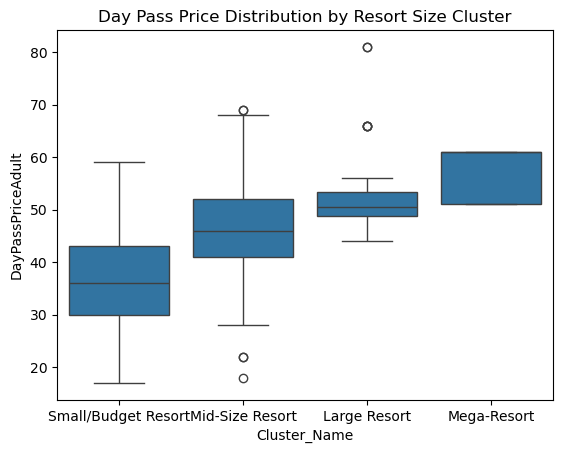

In [81]:
cluster_order = ['Small/Budget Resort', 'Mid-Size Resort', 'Large Resort', 'Mega-Resort']
sns.boxplot(data=df_unsupervised, x = 'Cluster_Name', y = 'DayPassPriceAdult', order = cluster_order)
plt.title('Day Pass Price Distribution by Resort Size Cluster')
plt.show()

#### **<u>Findings</u>**

Unlike supervised learning models, with unsupervised learning there aren't any metrics to make predictions against. Instead, it relies on detecting patterns to find the natural groups in the data. 

To discover patterns in the dataset, we used PCA to compress 7 feature dimensions down to 2 components to preserve the dataset variance. Through the Explained Variance Ratio and dimensionality reduction, we determined that the 2 best combinations of all 7 original features were PC1 and PC2 which contributed nearly 85% of data variation.  

Using standard cluster evaluation techniques including the Elbow Method and Silhouette Score, we tested different grouping sizes and determined  that dividing the resorts into 4 groups had the optimal cluster separation based on scale. 

Through K-Means, we discovered 4 segmented groups, although the fourth group may be outliers as they were mega-resorts. Their data points were too few to draw from, especially with properties so large and distinct from the rest of the resorts in the dataset. 

